In [ ]:
!pip install -q kaggle

In [ ]:
!mkdir -p ~/.kaggle

!echo "KGAT_0151e067ec6e1132d38e68381e5f2dc9" > ~/.kaggle/access_token

!chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d shuvoalok/raf-db-dataset

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
100% 37.7M/37.7M [00:03<00:00, 13.0MB/s]



In [ ]:
!unzip -o raf-db-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: DATASET/train/5/train_00987_aligned.jpg  
  inflating: DATASET/train/5/train_00990_aligned.jpg  
  inflating: DATASET/train/5/train_00991_aligned.jpg  
  inflating: DATASET/train/5/train_00992_aligned.jpg  
  inflating: DATASET/train/5/train_01002_aligned.jpg  
  inflating: DATASET/train/5/train_01010_aligned.jpg  
  inflating: DATASET/train/5/train_01011_aligned.jpg  
  inflating: DATASET/train/5/train_01013_aligned.jpg  
  inflating: DATASET/train/5/train_01015_aligned.jpg  
  inflating: DATASET/train/5/train_01017_aligned.jpg  
  inflating: DATASET/train/5/train_01039_aligned.jpg  
  inflating: DATASET/train/5/train_01048_aligned.jpg  
  inflating: DATASET/train/5/train_01049_aligned.jpg  
  inflating: DATASET/train/5/train_01053_aligned.jpg  
  inflating: DATASET/train/5/train_01070_aligned.jpg  
  inflating: DATASET/train/5/train_01074_aligned.jpg  
  inflating: DATASET/train/5/train_01078_aligned.jpg  
  inflating: D

In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:10])
    print("-"*80)

/content
Folders: ['.config', 'DATASET', 'sample_data']
Files: ['raf-db-dataset.zip', 'train_labels.csv', 'test_labels.csv']
--------------------------------------------------------------------------------
/content/.config
Folders: ['logs', 'configurations']
Files: ['default_configs.db', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', '.last_survey_prompt.yaml', 'config_sentinel', '.last_update_check.json', 'active_config', '.last_opt_in_prompt.yaml', 'gce']
--------------------------------------------------------------------------------
/content/.config/logs
Folders: ['2026.06.04']
Files: []
--------------------------------------------------------------------------------
/content/.config/logs/2026.06.04
Folders: []
Files: ['13.39.12.467650.log', '13.39.24.274402.log', '13.38.54.010366.log', '13.39.36.079406.log', '13.39.37.138439.log', '13.39.22.644527.log']
--------------------------------------------------------------------------------
/content/.config/configuratio

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

import torch

from torchvision import datasets

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
TRAIN_DIR="/content/DATASET/train"
TEST_DIR="/content/DATASET/test"

In [ ]:
train_dataset=datasets.ImageFolder(TRAIN_DIR)

test_dataset=datasets.ImageFolder(TEST_DIR)

print("Train Images :",len(train_dataset))
print("Test Images :",len(test_dataset))

Train Images : 12271
Test Images : 3068


In [ ]:
class_names=train_dataset.classes

print(class_names)

['1', '2', '3', '4', '5', '6', '7']


In [ ]:
emotion_labels={
'1':'Surprise',
'2':'Fear',
'3':'Disgust',
'4':'Happy',
'5':'Sad',
'6':'Angry',
'7':'Neutral'
}

print(emotion_labels)

{'1': 'Surprise', '2': 'Fear', '3': 'Disgust', '4': 'Happy', '5': 'Sad', '6': 'Angry', '7': 'Neutral'}


In [ ]:
train_count={}

for cls in class_names:

    folder=os.path.join(TRAIN_DIR,cls)

    train_count[emotion_labels[cls]]=len(os.listdir(folder))

train_count

{'Surprise': 1290,
 'Fear': 281,
 'Disgust': 717,
 'Happy': 4772,
 'Sad': 1982,
 'Angry': 705,
 'Neutral': 2524}

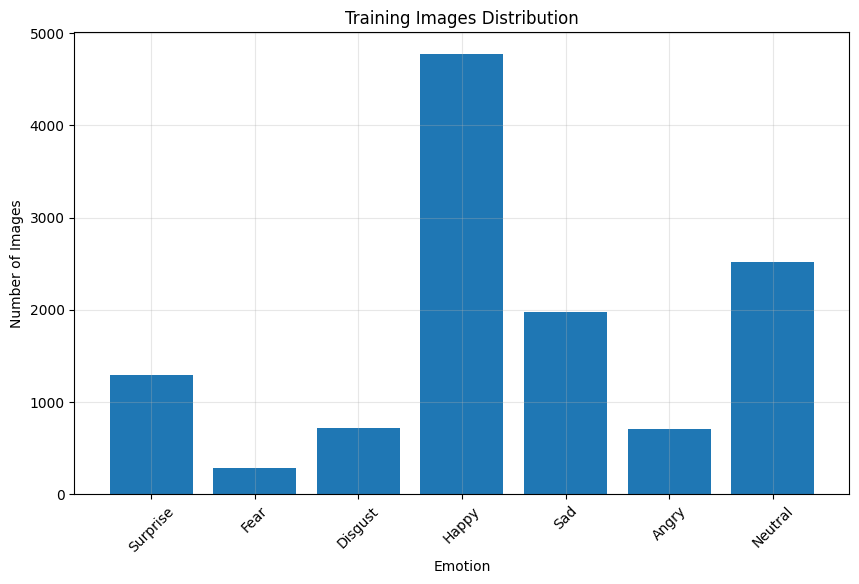

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(train_count.keys(),train_count.values())

plt.title("Training Images Distribution")

plt.xlabel("Emotion")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

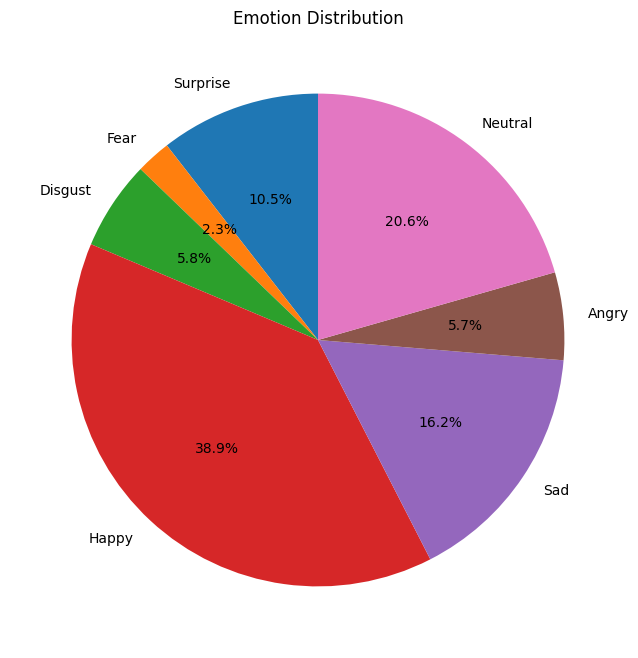

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(

train_count.values(),

labels=train_count.keys(),

autopct="%1.1f%%",

startangle=90

)

plt.title("Emotion Distribution")

plt.show()

In [ ]:
print("Training Images :",sum(train_count.values()))

test_count={}

for cls in class_names:

    folder=os.path.join(TEST_DIR,cls)

    test_count[emotion_labels[cls]]=len(os.listdir(folder))

print("Testing Images :",sum(test_count.values()))

Training Images : 12271
Testing Images : 3068


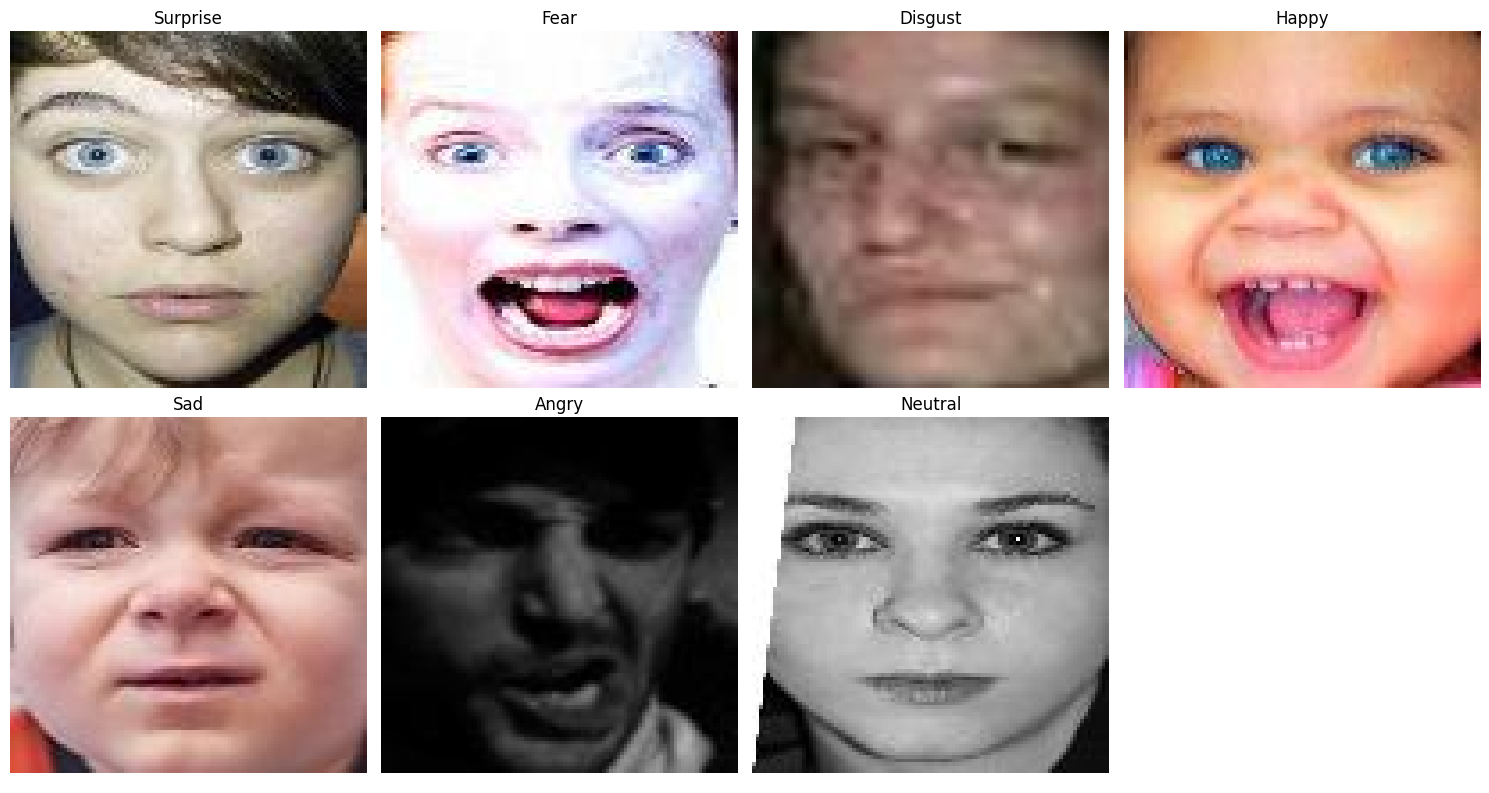

In [ ]:
fig,axes=plt.subplots(2,4,figsize=(15,8))

axes=axes.flatten()

for i,emotion in enumerate(class_names):

    folder=os.path.join(TRAIN_DIR,emotion)

    img=random.choice(os.listdir(folder))

    img_path=os.path.join(folder,img)

    image=Image.open(img_path)

    axes[i].imshow(image)

    axes[i].set_title(emotion_labels[emotion])

    axes[i].axis("off")

axes[-1].axis("off")

plt.tight_layout()

plt.show()

In [ ]:
widths=[]

heights=[]

for cls in class_names:

    folder=os.path.join(TRAIN_DIR,cls)

    files=os.listdir(folder)[:300]

    for file in files:

        img=Image.open(os.path.join(folder,file))

        w,h=img.size

        widths.append(w)

        heights.append(h)

print("Minimum Width :",min(widths))
print("Maximum Width :",max(widths))

print("Minimum Height :",min(heights))
print("Maximum Height :",max(heights))

Minimum Width : 100
Maximum Width : 100
Minimum Height : 100
Maximum Height : 100


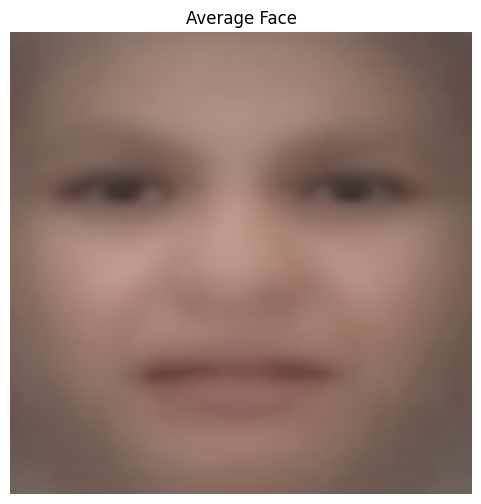

In [ ]:
sample=[]

for cls in class_names:

    folder=os.path.join(TRAIN_DIR,cls)

    files=os.listdir(folder)[:50]

    for file in files:

        img=cv2.imread(os.path.join(folder,file))

        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        img=cv2.resize(img,(224,224))

        sample.append(img)

sample=np.array(sample)

mean_image=np.mean(sample,axis=0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(mean_image)

plt.title("Average Face")

plt.axis("off")

plt.show()

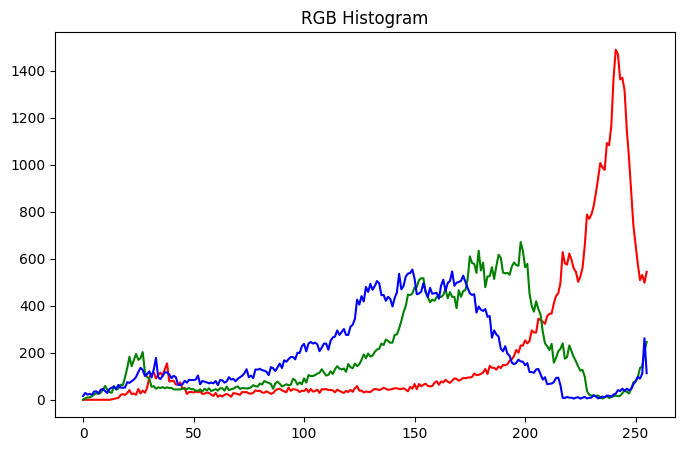

In [ ]:
img=sample[0]

colors=("r","g","b")

plt.figure(figsize=(8,5))

for i,color in enumerate(colors):

    hist=cv2.calcHist([img],[i],None,[256],[0,256])

    plt.plot(hist,color=color)

plt.title("RGB Histogram")

plt.show()

In [ ]:
!pip install -q albumentations
!pip install -q opencv-python-headless

In [ ]:
import cv2
import numpy as np

from albumentations import (
    Compose,
    Resize,
    HorizontalFlip,
    ShiftScaleRotate,
    RandomBrightnessContrast,
    HueSaturationValue,
    CLAHE,
    CoarseDropout,
    Normalize
)

from albumentations.pytorch import ToTensorV2

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [ ]:
train_transform = Compose([

    Resize(224,224),

    HorizontalFlip(p=0.5),

    ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),

    RandomBrightnessContrast(
        brightness_limit=0.20,
        contrast_limit=0.20,
        p=0.5
    ),

    HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=15,
        val_shift_limit=10,
        p=0.3
    ),

    CLAHE(
        clip_limit=2.0,
        p=0.3
    ),

    CoarseDropout(
        max_holes=6,
        max_height=24,
        max_width=24,
        p=0.3
    ),

    Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()

])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1009/3948706722.py:33: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  CoarseDropout(


In [ ]:
valid_transform = Compose([

    Resize(224,224),

    Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()

])

In [ ]:
class RAFDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.images = []

        self.labels = []

        classes = sorted(os.listdir(root_dir))

        for cls in classes:

            folder = os.path.join(root_dir, cls)

            if not os.path.isdir(folder):
                continue

            for img in os.listdir(folder):

                self.images.append(os.path.join(folder, img))

                self.labels.append(int(cls)-1)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        image = cv2.imread(self.images[index])

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = self.labels[index]

        if self.transform:

            image = self.transform(image=image)["image"]

        return image, label

In [ ]:
train_dataset = RAFDataset(
    TRAIN_DIR,
    transform=train_transform
)

valid_dataset = RAFDataset(
    TEST_DIR,
    transform=valid_transform
)

print("Training Images :",len(train_dataset))
print("Testing Images :",len(valid_dataset))

Training Images : 12271
Testing Images : 3068


In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    drop_last=True

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

In [ ]:
images,labels=next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


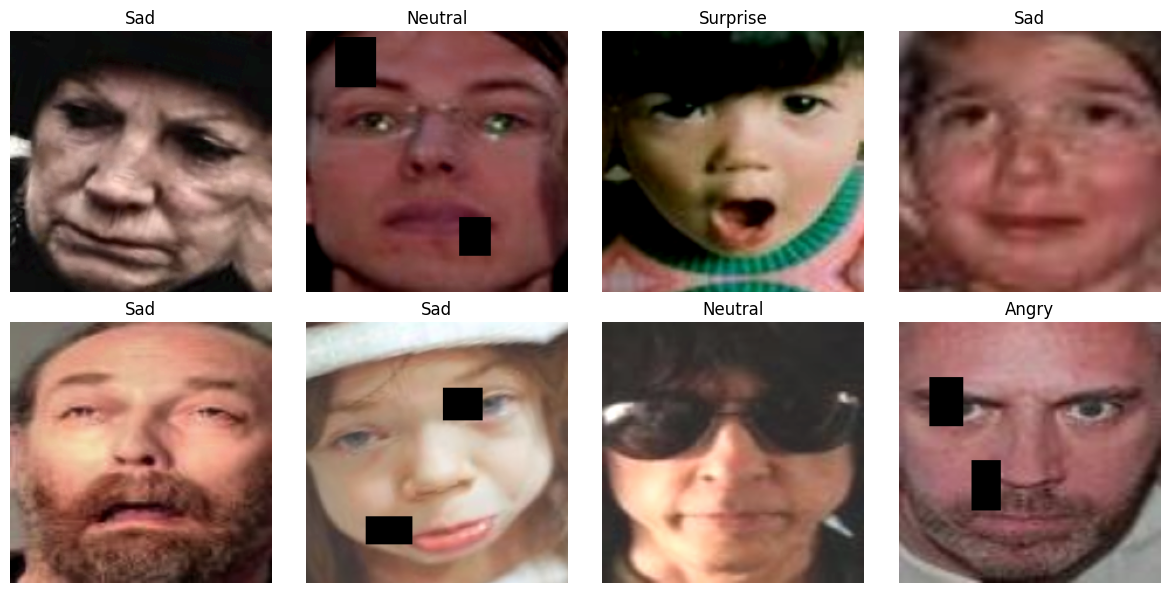

In [ ]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(2,4,figsize=(12,6))

axes=axes.flatten()

for i in range(8):

    img=images[i].permute(1,2,0).cpu().numpy()

    img=img*np.array([0.229,0.224,0.225])+np.array([0.485,0.456,0.406])

    img=np.clip(img,0,1)

    axes[i].imshow(img)

    axes[i].set_title(emotion_labels[str(labels[i].item()+1)])

    axes[i].axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from collections import Counter

counter=Counter(train_dataset.labels)

print(counter)

Counter({3: 4772, 6: 2524, 4: 1982, 0: 1290, 2: 717, 5: 705, 1: 281})


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes=np.unique(train_dataset.labels)

weights=compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=train_dataset.labels

)

class_weights=torch.tensor(weights,dtype=torch.float32)

print(class_weights)

tensor([1.3589, 6.2384, 2.4449, 0.3674, 0.8845, 2.4865, 0.6945])


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
class_weights=class_weights.to(device)

In [ ]:
torch.set_float32_matmul_precision("high")

In [ ]:
print("Data Pipeline Ready")

Data Pipeline Ready


In [ ]:
import timm

import torch.nn as nn

from torch.optim import AdamW

from torch.optim.lr_scheduler import CosineAnnealingLR

from torch.cuda.amp import autocast, GradScaler

In [ ]:
model = timm.create_model(

    "convnextv2_base.fcmae_ft_in22k_in1k",

    pretrained=True,

    num_classes=7

)

model=model.to(device)

print(model)

model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=512, out_features=128, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), strid

In [ ]:
for param in model.parameters():

    param.requires_grad=False

In [ ]:
in_features=model.head.fc.in_features

model.head.fc=nn.Sequential(

    nn.Linear(in_features,1024),

    nn.GELU(),

    nn.BatchNorm1d(1024),

    nn.Dropout(0.40),

    nn.Linear(1024,512),

    nn.GELU(),

    nn.BatchNorm1d(512),

    nn.Dropout(0.30),

    nn.Linear(512,256),

    nn.GELU(),

    nn.Dropout(0.20),

    nn.Linear(256,7)

)

model=model.to(device)

In [ ]:
for param in model.head.parameters():

    param.requires_grad=True

In [ ]:
trainable=0

total=0

for p in model.parameters():

    total+=p.numel()

    if p.requires_grad:

        trainable+=p.numel()

print("Trainable :",trainable)

print("Total :",total)

Trainable : 1712647
Total : 89403399


In [ ]:
criterion=nn.CrossEntropyLoss(

    label_smoothing=0.1,

    weight=class_weights

)

In [ ]:
optimizer=AdamW(

    model.parameters(),

    lr=3e-4,

    weight_decay=0.05

)

In [ ]:
scheduler=CosineAnnealingLR(

    optimizer,

    T_max=40,

    eta_min=1e-6

)

In [ ]:
scaler=GradScaler()

/tmp/ipykernel_1009/3759304271.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


In [ ]:
def accuracy(outputs,labels):

    _,pred=torch.max(outputs,1)

    correct=(pred==labels).sum().item()

    return correct/labels.size(0)

In [ ]:
history={

'train_loss':[],

'valid_loss':[],

'train_acc':[],

'valid_acc':[]

}

In [ ]:
best_acc=0

patience=8

counter=0

In [ ]:
SAVE_PATH="best_convnextv2_rafdb.pth"

In [ ]:
dummy=torch.randn(2,3,224,224).to(device)

out=model(dummy)

print(out.shape)

torch.Size([2, 7])


In [ ]:
def unfreeze_model(model):

    for param in model.parameters():

        param.requires_grad=True

    print("Entire ConvNeXt V2 Unfrozen")

In [ ]:
def change_optimizer():

    optimizer=AdamW(

        model.parameters(),

        lr=1e-5,

        weight_decay=0.05

    )

    return optimizer

In [ ]:
print(model)

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=512, out_features=128, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), strid

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):

    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = outputs.max(1)

        running_correct += preds.eq(labels).sum().item()

        total += labels.size(0)

        pbar.set_postfix({

            "Loss": running_loss/(total/labels.size(0)),

            "Acc":100.*running_correct/total

        })

    epoch_loss = running_loss/len(loader)

    epoch_acc = 100*running_correct/total

    return epoch_loss, epoch_acc

In [ ]:
@torch.no_grad()

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    running_correct = 0

    total = 0

    y_true=[]

    y_pred=[]

    for images, labels in loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        _,preds = outputs.max(1)

        running_correct += preds.eq(labels).sum().item()

        total += labels.size(0)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

    epoch_loss = running_loss/len(loader)

    epoch_acc = 100*running_correct/total

    return epoch_loss,epoch_acc,y_true,y_pred

In [ ]:
history = {

    "train_loss":[],

    "train_acc":[],

    "val_loss":[],

    "val_acc":[]

}

In [ ]:
best_accuracy = 0

patience = 8

counter = 0

In [ ]:
# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
NUM_CLASSES = 7
IMAGE_SIZE = 224

In [ ]:
print(type(model))
print(type(train_loader))
print(type(valid_loader))
print(type(optimizer))
print(type(criterion))
print(type(scheduler))
print(type(scaler))
print(device)

<class 'timm.models.convnext.ConvNeXt'>
<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.optim.adamw.AdamW'>
<class 'torch.nn.modules.loss.CrossEntropyLoss'>
<class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
<class 'torch.cuda.amp.grad_scaler.GradScaler'>
cuda


In [ ]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss,train_acc = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        scaler,

        device

    )

    val_loss,val_acc,y_true,y_pred = validate(

        model,

        valid_loader,

        criterion,

        device

    )

    scheduler.step()

    history["train_loss"].append(train_loss)

    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)

    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(

            model.state_dict(),

            "best_convnextv2.pth"

        )

        print("Model Saved")

        counter = 0

    else:

        counter += 1

        print("Early Stop Counter :",counter)

    if counter >= patience:

        print("Early Stopping")

        break


Epoch 1/30


  0%|          | 0/383 [00:00<?, ?it/s]/tmp/ipykernel_1009/1654044140.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 383/383 [01:25<00:00,  4.48it/s, Loss=1.74, Acc=52.9]


Train Loss : 1.7394
Train Acc  : 52.86%
Val Loss   : 1.8522
Val Acc    : 64.02%
Model Saved

Epoch 2/30


100%|██████████| 383/383 [01:21<00:00,  4.67it/s, Loss=1.58, Acc=61.6]


Train Loss : 1.5791
Train Acc  : 61.64%
Val Loss   : 1.7797
Val Acc    : 68.19%
Model Saved

Epoch 3/30


...

100%|██████████| 383/383 [01:22<00:00,  4.65it/s, Loss=1.03, Acc=85.4]


Train Loss : 1.0277
Train Acc  : 85.41%
Val Loss   : 1.7424
Val Acc    : 74.22%
Model Saved

Epoch 27/30


100%|██████████| 383/383 [01:22<00:00,  4.63it/s, Loss=1.03, Acc=85.4]


Train Loss : 1.0295
Train Acc  : 85.39%
Val Loss   : 1.7181
Val Acc    : 74.58%
Model Saved

Epoch 28/30


100%|██████████| 383/383 [01:22<00:00,  4.65it/s, Loss=1.02, Acc=86]


In [ ]:
print(f"\nBest Validation Accuracy : {best_accuracy:.2f}%")


Best Validation Accuracy : 74.80%


In [ ]:
model.load_state_dict(torch.load("best_convnextv2.pth"))

model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


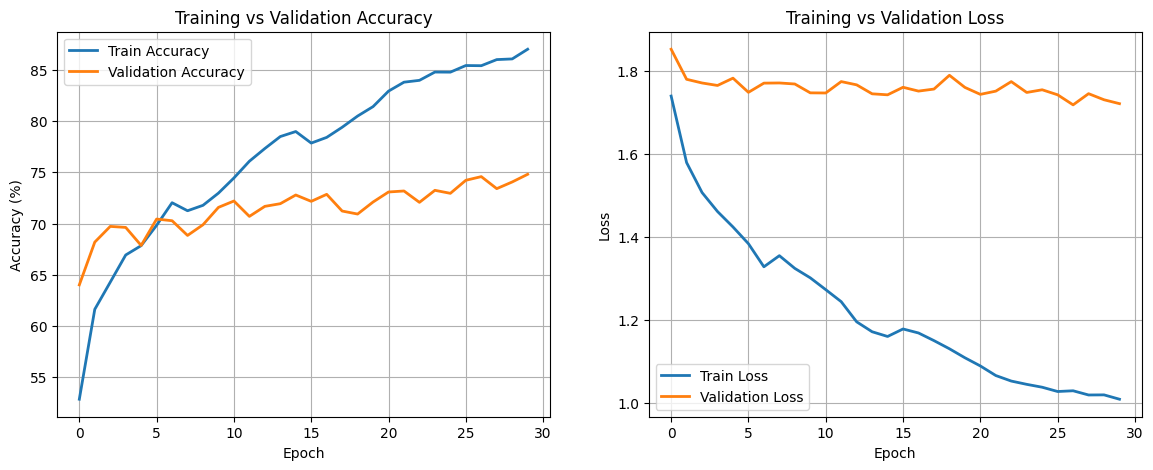

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history["train_acc"],label="Train Accuracy",linewidth=2)

plt.plot(history["val_acc"],label="Validation Accuracy",linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.subplot(1,2,2)

plt.plot(history["train_loss"],label="Train Loss",linewidth=2)

plt.plot(history["val_loss"],label="Validation Loss",linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
y_true = []

y_pred = []

model.eval()

with torch.no_grad():

    for images,labels in valid_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(predicted.cpu().numpy())

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true,y_pred)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 74.80%


In [ ]:
from sklearn.metrics import classification_report

target_names = [

    "Surprise",

    "Fear",

    "Disgust",

    "Happy",

    "Sad",

    "Angry",

    "Neutral"

]

print(classification_report(

    y_true,

    y_pred,

    target_names=target_names

))

              precision    recall  f1-score   support

    Surprise       0.75      0.72      0.74       329
        Fear       0.52      0.55      0.54        74
     Disgust       0.34      0.44      0.38       160
       Happy       0.91      0.85      0.88      1185
         Sad       0.71      0.67      0.69       478
       Angry       0.60      0.66      0.63       162
     Neutral       0.71      0.76      0.73       680

    accuracy                           0.75      3068
   macro avg       0.65      0.66      0.65      3068
weighted avg       0.76      0.75      0.75      3068



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true,y_pred)

print(cm)

[[ 238    9   14    9   11    9   39]
 [  12   41    4    4    3    6    4]
 [   5    4   70   20   18    6   37]
 [  17    8   36 1002   37   21   64]
 [  11    7   36   27  318   13   66]
 [   8    8   11   11   11  107    6]
 [  27    2   35   29   52   16  519]]


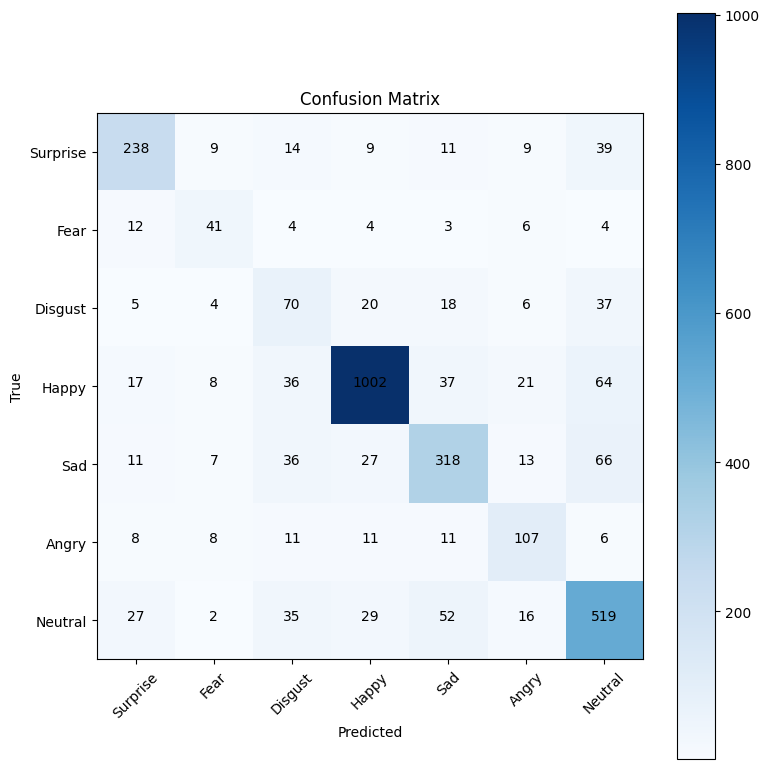

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.imshow(cm,cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(7),target_names,rotation=45)

plt.yticks(range(7),target_names)

for i in range(7):

    for j in range(7):

        plt.text(

            j,

            i,

            cm[i,j],

            ha="center",

            color="black"

        )

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

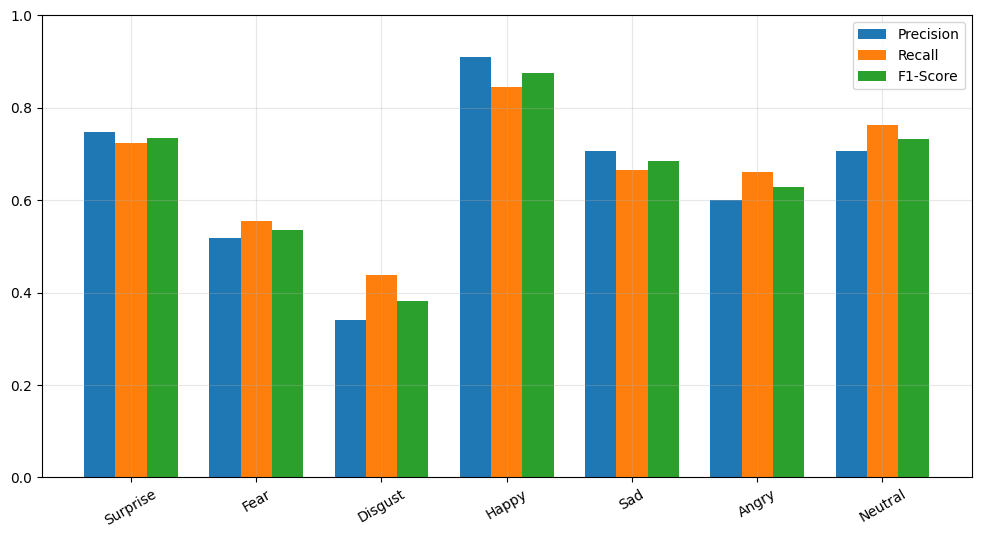

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision,recall,f1,_ = precision_recall_fscore_support(

    y_true,

    y_pred

)

x = np.arange(7)

width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x-width,precision,width,label="Precision")

plt.bar(x,recall,width,label="Recall")

plt.bar(x+width,f1,width,label="F1-Score")

plt.xticks(x,target_names,rotation=30)

plt.ylim(0,1)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

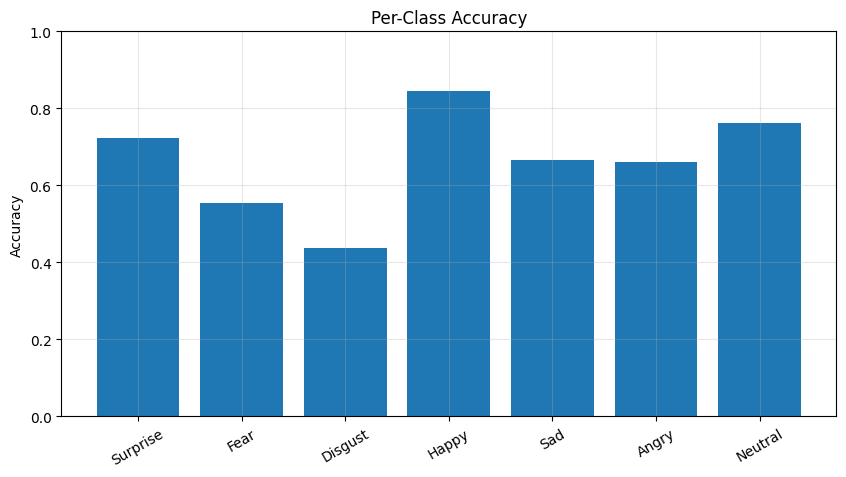

In [ ]:
class_acc = cm.diagonal()/cm.sum(axis=1)

plt.figure(figsize=(10,5))

plt.bar(target_names,class_acc)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Per-Class Accuracy")

plt.grid(alpha=0.3)

plt.xticks(rotation=30)

plt.show()

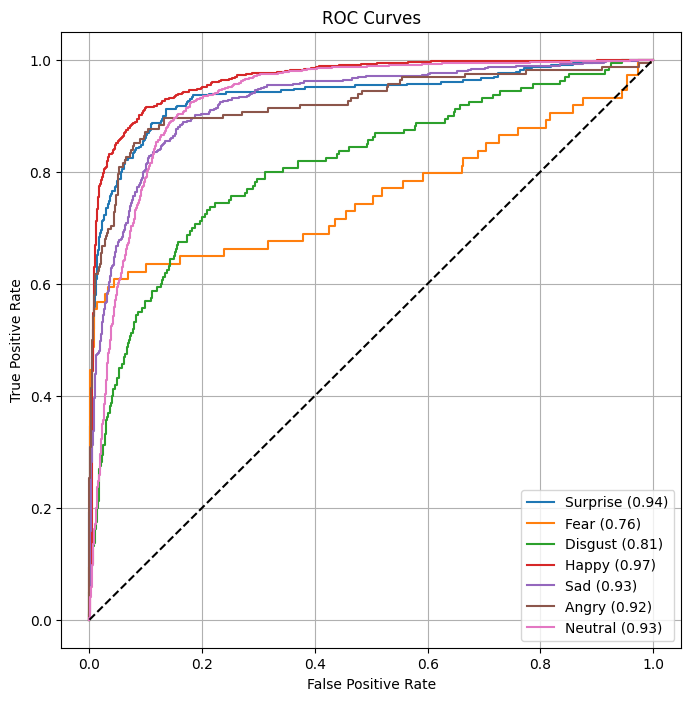

In [ ]:
from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve

from sklearn.metrics import auc

import torch.nn.functional as F

model.eval()

probabilities=[]

labels_all=[]

with torch.no_grad():

    for images,labels in valid_loader:

        images=images.to(device)

        outputs=model(images)

        probs=F.softmax(outputs,dim=1)

        probabilities.extend(probs.cpu().numpy())

        labels_all.extend(labels.numpy())

probabilities=np.array(probabilities)

labels_all=np.array(labels_all)

labels_bin=label_binarize(labels_all,classes=np.arange(7))

plt.figure(figsize=(8,8))

for i in range(7):

    fpr,tpr,_=roc_curve(

        labels_bin[:,i],

        probabilities[:,i]

    )

    roc_auc=auc(fpr,tpr)

    plt.plot(

        fpr,

        tpr,

        label=f"{target_names[i]} ({roc_auc:.2f})"

    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.grid()

plt.show()

In [ ]:
torch.save(

    model.state_dict(),

    "Emotion_Recognition_ConvNeXtV2.pth"

)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 104.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=dab32b183ae7b5909965b4dbb49aa8fdcc6480a73a637f0f9e4cc2c6d63160bd
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Enable gradients
for p in model.parameters():
    p.requires_grad = True

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving emotion.webp to emotion (1).webp


In [ ]:
image = Image.open(image_path).convert("RGB")
image = image.resize((224,224))

rgb_img = np.array(image).astype(np.float32) / 255.0

input_tensor = valid_transform(
    image=np.array(image)
)["image"]

input_tensor = input_tensor.unsqueeze(0).to(device)

In [ ]:
def reshape_transform(tensor):
    return tensor

In [ ]:
target_layers = [
    model.stages[3].blocks[2].norm
]

In [ ]:
output = model(input_tensor)

predicted_class = output.argmax(dim=1).item()

print("Predicted Class :", predicted_class)

targets = [
    ClassifierOutputTarget(predicted_class)
]

Predicted Class : 4


In [ ]:
cam = GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

In [ ]:
!pip show grad-cam

Name: grad-cam
Version: 1.5.5
Summary: Many Class Activation Map methods implemented in Pytorch for classification, segmentation, object detection and more
Home-page: https://github.com/jacobgil/pytorch-grad-cam
Author: Jacob Gildenblat
Author-email: jacob.gildenblat@gmail.com
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, opencv-python, Pillow, scikit-learn, torch, torchvision, tqdm, ttach
Required-by: 


In [ ]:
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

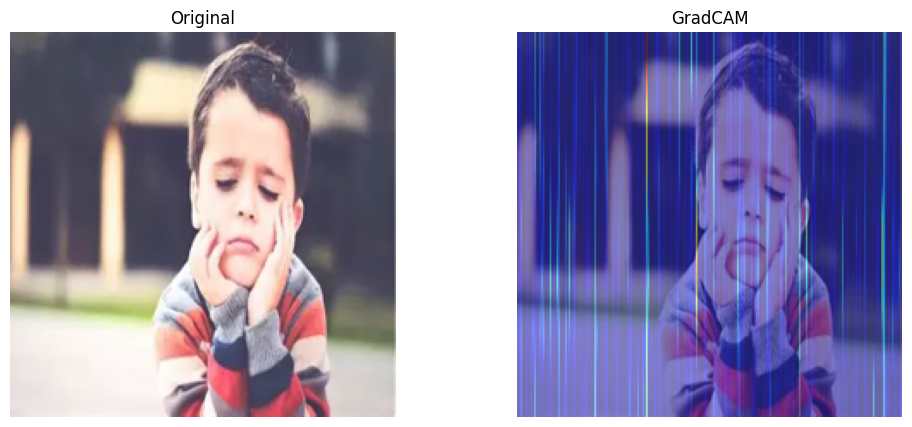

In [ ]:
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("GradCAM")
plt.axis("off")

plt.show()

In [ ]:
def predict(image_path):

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))

    arr = np.array(image)

    tensor = valid_transform(image=arr)["image"]
    tensor = tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        probs = torch.softmax(output,1)

        values, indices = torch.topk(probs,3)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Top 3 Predictions\n")

    for v,i in zip(values[0],indices[0]):

        print(
            target_names[i.item()],
            " : ",
            round(v.item()*100,2),
            "%"
        )

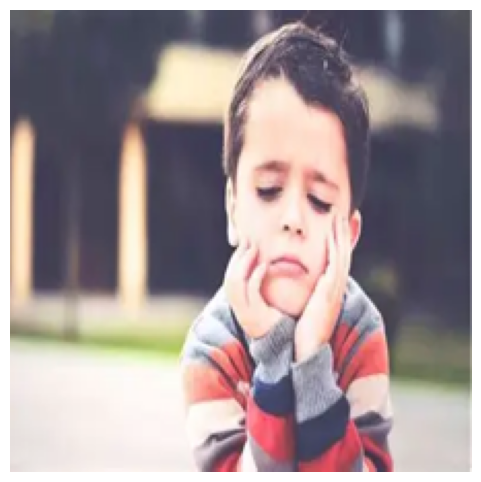

Top 3 Predictions

Sad  :  74.65 %
Fear  :  11.74 %
Disgust  :  8.06 %


In [ ]:
predict(image_path)

In [ ]:
torch.save(
    model.state_dict(),
    "Emotion_Recognition_ConvNeXtV2.pth"
)

print("Weights Saved Successfully")

Weights Saved Successfully


In [ ]:
torch.save(
    model,
    "Complete_Emotion_Model.pt"
)

In [ ]:
total = sum(p.numel() for p in model.parameters())

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :",total)
print("Trainable :",trainable)

Total Parameters : 89403399
Trainable : 89403399


In [ ]:
import time

dummy = torch.randn(
    1,
    3,
    224,
    224
).to(device)

start = time.time()

for _ in range(100):

    with torch.no_grad():

        _ = model(dummy)

end = time.time()

avg = (end-start)/100

print("Average Inference Time :",avg)
print("Estimated FPS :",1/avg)

Average Inference Time : 0.019770541191101075
Estimated FPS : 50.58030482494381


In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    "training_history.csv",
    index=False
)

history_df.head()

,train_loss,train_acc,val_loss,val_acc
0,1.739368,52.863903,1.852166,64.015645
1,1.579126,61.635117,1.779736,68.187744
2,1.506948,64.278721,1.770865,69.719687
3,1.461230,66.930483,1.764873,69.621904
4,1.424073,67.844321,1.782473,67.861799


In [ ]:
from google.colab import files

files.download(
    "Emotion_Recognition_ConvNeXtV2.pth"
)

files.download(
    "training_history.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile requirements.txt

torch
torchvision
timm
albumentations
opencv-python-headless
numpy
matplotlib
Pillow
streamlit
grad-cam

Overwriting requirements.txt


In [ ]:
!pip install -q streamlit timm albumentations opencv-python-headless grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 66.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
print(st.__version__)

1.58.0


In [ ]:
import torch.nn as nn

model.head.fc = nn.Sequential(
    nn.Linear(1024,1024),
    nn.GELU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.4),

    nn.Linear(1024,512),
    nn.GELU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),

    nn.Linear(512,256),
    nn.GELU(),
    nn.Dropout(0.2),

    nn.Linear(256,7)
)

In [ ]:
model.load_state_dict(
    torch.load(
        "Emotion_Recognition_ConvNeXtV2.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=512, out_features=128, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), strid

In [ ]:
!pip install -q streamlit

In [ ]:
%%writefile app.py

Overwriting app.py


In [ ]:
import streamlit as st
import torch
import torch.nn as nn
import timm
import numpy as np
import pandas as pd

from PIL import Image
from albumentations import Compose, Resize, Normalize
from albumentations.pytorch import ToTensorV2

# ----------------------------
# Configuration
# ----------------------------

st.set_page_config(
    page_title="Emotion Detection",
    page_icon="😊",
    layout="centered"
)

emotion_names = {
    0: "Surprise",
    1: "Fear",
    2: "Disgust",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Neutral"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ----------------------------
# Load Model
# ----------------------------

@st.cache_resource
def load_model():

    model = timm.create_model(
        "convnextv2_base.fcmae_ft_in22k_in1k",
        pretrained=False,
        num_classes=7
    )

    # Recreate custom classifier exactly as during training
    model.head.fc = nn.Sequential(
        nn.Linear(1024,1024),
        nn.GELU(),
        nn.BatchNorm1d(1024),
        nn.Dropout(0.4),

        nn.Linear(1024,512),
        nn.GELU(),
        nn.BatchNorm1d(512),
        nn.Dropout(0.3),

        nn.Linear(512,256),
        nn.GELU(),
        nn.Dropout(0.2),

        nn.Linear(256,7)
    )

    state_dict = torch.load(
        "Emotion_Recognition_ConvNeXtV2.pth",
        map_location=device
    )

    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model


model = load_model()


# ----------------------------
# Image Transform
# ----------------------------

transform = Compose([
    Resize(224,224),
    Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),
    ToTensorV2()
])


# ----------------------------
# Streamlit UI
# ----------------------------

st.title("😊 Emotion Detection System")

st.write(
    "Upload a face image and the trained ConvNeXtV2 model will predict the emotion."
)

uploaded = st.file_uploader(
    "Upload Image",
    type=["jpg","jpeg","png","webp"]
)

if uploaded is not None:

    image = Image.open(uploaded).convert("RGB")

    st.image(
        image,
        caption="Uploaded Image",
        use_container_width=True
    )

    image_np = np.array(image)

    tensor = transform(image=image_np)["image"]
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(tensor)

        probs = torch.softmax(output, dim=1)

        confidence, pred = torch.max(probs,1)

    st.success(
        f"Predicted Emotion : **{emotion_names[pred.item()]}**"
    )

    st.write(
        f"Confidence : **{confidence.item()*100:.2f}%**"
    )

    st.subheader("Prediction Probabilities")

    df = pd.DataFrame({
        "Emotion":[emotion_names[i] for i in range(7)],
        "Probability":probs.cpu().numpy()[0]
    })

    st.bar_chart(
        df.set_index("Emotion")
    )

    st.subheader("Top 3 Predictions")

    values, indices = torch.topk(probs,3)

    for score, idx in zip(values[0], indices[0]):

        st.write(
            f"**{emotion_names[idx.item()]}** : {score.item()*100:.2f}%"
        )

2026-07-05 08:52:30.008 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 08:52:30.012 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 08:52:33.862 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 08:52:34.082 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-05 08:52:34.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 08:52:34.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 08:52:34.091 Thread 'MainThread'

In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
!ls

 app.py				       IMG_20190526_102525.jpg
 best_convnextv2.pth		       raf-db-dataset.zip
 Complete_Emotion_Model.pt	       requirements.txt
 DATASET			       sample_data
'emotion (1).webp'		       test_labels.csv
 Emotion_Recognition_ConvNeXtV2.pth    training_history.csv
 emotion.webp			       train_labels.csv
 haarcascade_frontalface_default.xml   webcam.py


In [ ]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("Y3G4rqDjI8aMplEaKCDZD73SQ68Q_58B7bxdLy4wHLrJ3Fztko")

In [ ]:
!streamlit run app.py > /content/log.txt 2>&1 &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://brave-zoos-lick.loca.lt
!curl https://loca.lt/mytunnelpassword
Mehak@2004
^C
